In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import packages
import torch
from Index_Generators.MultIndexGenerator import MultIndexGenerator
import matplotlib.pyplot as plt

In [3]:
# Build a multiple index generator
h_size = 16
num_indices = 3
N = [10, 8, 12]
MyMIG = MultIndexGenerator(LSTM_hidden_size=h_size, FFNN_hidden_size=[5, 4, 6], num_categories=N, FFNN_num_layers=[3, 2, 4], weight=[None, None, None])

In [12]:
# Run the multiple index generator (2 indices)
num_samples = 1000
input_index_vector = torch.empty(num_samples, num_indices)
for i in range(len(N)):
    input_index_vector[:, i] = torch.randint(0, N[i], (num_samples,)).float()
h0 = torch.randn(num_samples, h_size)
c0 = torch.randn(num_samples, h_size)
output_index_vector, logProb, entropy, h1, c1 = MyMIG(input_index_vector, h0, c0)
output_index_vector, logProb, entropy, h2, c2 = MyMIG(output_index_vector.float(), h1, c1)

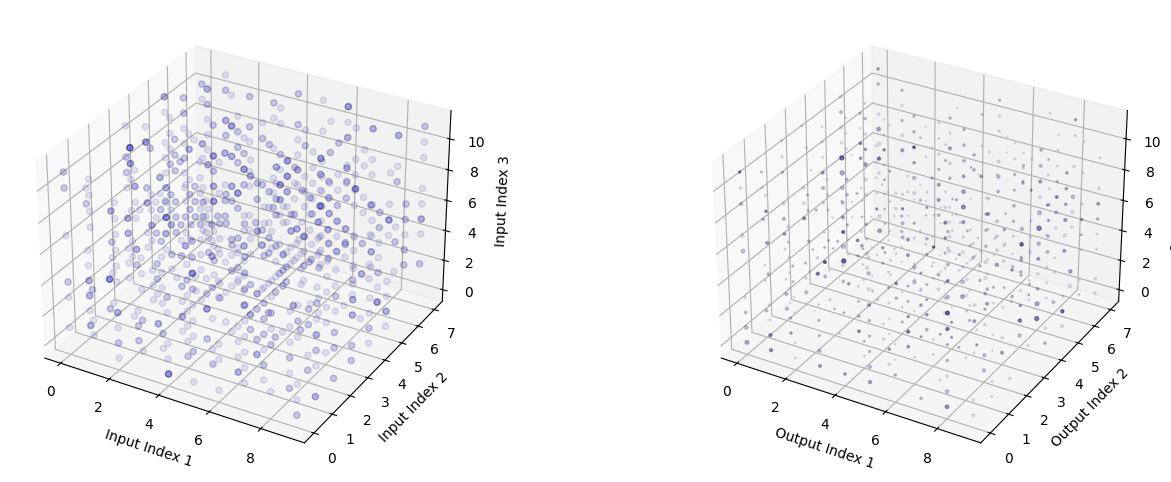

In [14]:
# Plot the results
x_input = input_index_vector[:,0].detach()
y_input = input_index_vector[:,1].detach()
z_input = input_index_vector[:,2].detach()
x_output = output_index_vector[:,0].detach()
y_output = output_index_vector[:,1].detach()
z_output = output_index_vector[:,2].detach()
sizes = torch.exp(logProb.detach()) * 2000 
fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x_input, y_input, z_input, color='blue', alpha=0.1, edgecolors='black')
ax1.set_xlabel("Input Index 1")
ax1.set_ylabel("Input Index 2")
ax1.set_zlabel("Input Index 3")  
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(x_output, y_output, z_output, s=sizes, color='blue', alpha=0.1, edgecolors='black')
ax2.set_xlabel("Output Index 1")
ax2.set_ylabel("Output Index 2")
ax2.set_zlabel("Output Index 3") 

plt.show()